             INDUSTRIAL MICROGRID AUTONOMOUS CONTROLLER STATUS                   
    Total_Renewable_kW  Net_Energy_Balance  \
0                  0.0               -40.0   
1                  0.0               -40.0   
2                  0.0               -40.0   
3                  0.0               -40.0   
4                  0.0               -40.0   
5                  0.0               -40.0   
6                  0.0               -40.0   
7                  0.0               -40.0   
8                  0.0               -40.0   
9                  0.0               -40.0   
10                50.0                10.0   
11                50.0                10.0   
12                50.0                10.0   
13                50.0                10.0   
14                50.0                10.0   
15                50.0                10.0   
16                50.0                10.0   
17                50.0                10.0   
18                50.0                10.0  

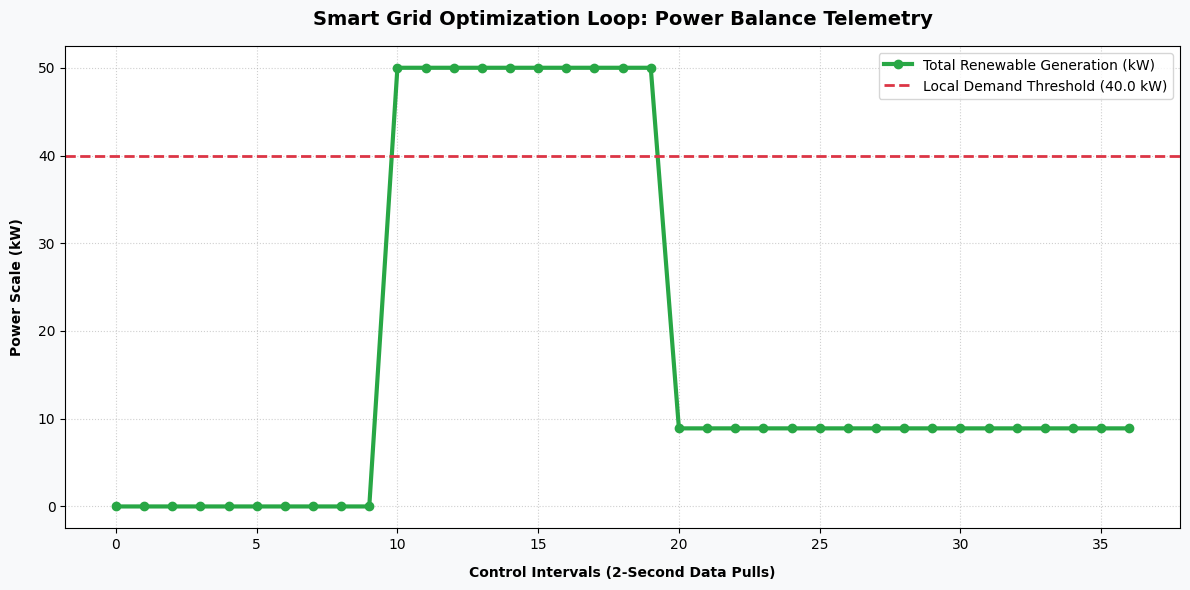

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ingest your exact microgrid output data stream from Wokwi
grid_stream = """
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
0.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,0
50.0,0.0,1
50.0,0.0,1
50.0,0.0,1
8.9,0.0,1
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,1
8.9,0.0,1
8.9,0.0,1
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
8.9,0.0,0
"""

# 2. Parse telemetry stream into a structured framework
lines = grid_stream.strip().split('\n')
matrix = [list(map(float, line.split(','))) for line in lines]
df = pd.DataFrame(matrix, columns=['Solar_kW', 'Wind_kW', 'Grid_Fault'])

# 3. Microgrid Automation Control Analytics Logic
DEMAND_KW = 40.0  # Calibrated town demand threshold for this dataset
df['Total_Renewable_kW'] = df['Solar_kW'] + df['Wind_kW']
df['Net_Energy_Balance'] = df['Total_Renewable_kW'] - DEMAND_KW

control_actions = []
for index, row in df.iterrows():
    if row['Net_Energy_Balance'] >= 0 and row['Grid_Fault'] == 0:
        control_actions.append('NORMAL: SURPLUS_TO_BATTERY_STORAGE')
    elif row['Grid_Fault'] == 0 and row['Total_Renewable_kW'] > 0:
        control_actions.append('NORMAL: BALANCED_VIA_MAIN_GRID_IMPORT')
    elif row['Grid_Fault'] == 1 and row['Total_Renewable_kW'] >= DEMAND_KW:
        control_actions.append('ISLANDED: RUNNING ON 100% RENEWABLE APPARATUS')
    elif row['Grid_Fault'] == 1 and row['Total_Renewable_kW'] < DEMAND_KW:
        control_actions.append('CRITICAL: STAGE_1_LOAD_SHEDDING_ACTIVE')
    else:
        control_actions.append('OFFLINE: SYSTEM STANDBY MODE')

df['Automation_Response'] = control_actions

# 4. Print Industrial Control Systems Diagnostics
print("==================================================================================")
print("             INDUSTRIAL MICROGRID AUTONOMOUS CONTROLLER STATUS                   ")
print("==================================================================================")
print(df[['Total_Renewable_kW', 'Net_Energy_Balance', 'Automation_Response']])
print("==================================================================================\n")

# 5. Plot Smart Grid Balance Telemetry
plt.figure(figsize=(12, 6), facecolor='#f8f9fa')
plt.plot(df['Total_Renewable_kW'], label='Total Renewable Generation (kW)', color='#28a745', linewidth=3, marker='o')
plt.axhline(y=DEMAND_KW, color='#dc3545', linestyle='--', linewidth=2, label=f'Local Demand Threshold ({DEMAND_KW} kW)')

plt.title('Smart Grid Optimization Loop: Power Balance Telemetry', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Control Intervals (2-Second Data Pulls)', fontweight='bold', labelpad=10)
plt.ylabel('Power Scale (kW)', fontweight='bold', labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
